# Lab Description

This lab aims to introduce you to the practical considerations when performing machine learning in the real world. Real data is generally not clean. We may be given data with gaps, outliers or irrelevant features. For models to perform well, we need to do some data cleaning to fix these issues, and decide what to consider a feature for the machine learning, and what to drop. 

> __Problem Statement__: Your aim is to predict the CHF from the dataset provided. You will need to think critically to clean up the data and perform feature selection and/or engineering.


#### Competition Rules: 
- No cheating! It would be against the spirit of the competition to search for the test data, for instance! 
- The winner will be the entry with the highest score submitted before the end of the lab on the unseen test data.
- To optimise hyperparameters, you may perform a grid search, random search, Bayesian optimisation, or some other optimisation technique. Specifically, entries where you have stumbled upon good hyperparameters by chance will be considered invalid.
- Entries that "luck out" and achieve a very high score against the test data despite having a modest score on the validation data will be considered invalid.
- You must not make decisions about hyperparameters based on the test score (for instance, if you perform a hyperparameter search, then run the testing code and find you have a low score, going back to the hyperparameter search again would be bad practice. This is an indirect form of data leakage).
  
#### Prize: 
- Pride!

# Exploring the Data

Pandas is used to open the csv file, explore its contents, and start to perform some feature cleanup. In Python, it is common to import a package while giving the package a shortened name. For example, in the cell below, we write `import pandas as pd` which sets `pd` as an alias for `pandas` so we can write `pd.read_csv(<filename>)` rather than `pandas.read_csv(<filename>)`.

In [1]:
import pandas as pd
import joblib
from joblib import Parallel

Now we use Pandas to load the training data as a Pandas dataframe called df. The `head` method of the df object prints the first few lines of the file. Study the data format and familiarise yourself with the type of data we have available.

In [2]:
df = pd.read_csv('https://github.com/MartianonEarth/ai4nth-summer-school/blob/ai-nth-bundle-2026/datasets/chf_train.csv?raw=true')
df.head()

,Number,Reference ID,Tube Diameter (m),Heated Length (m),Pressure (kPa),Mass Flux (kg/m^2/s),Outlet Quality,Inlet Subcooling (kJ/kg),Inlet Temperature (degreeC ),CHF (kW/m^2),Reference name
0,1650,9,0.00999,0.6,2991.0,220.0,0.751,839.0,39.61,2002.0,"Becker 1963 AE 114, 1965 AE-177"
1,1651,9,0.00999,0.6,2305.0,225.0,0.737,776.0,39.16,2009.0,"Becker 1963 AE 114, 1965 AE-177"
2,1652,9,0.00999,0.6,2599.0,221.0,0.750,812.0,37.54,2009.0,"Becker 1963 AE 114, 1965 AE-177"
3,1653,9,0.00999,0.6,2040.0,228.0,0.725,749.0,38.75,2006.0,"Becker 1963 AE 114, 1965 AE-177"
4,1654,9,0.00999,0.6,1775.0,228.0,0.726,717.0,38.86,1998.0,"Becker 1963 AE 114, 1965 AE-177"


## Exploring the data

Let's explore the data. The dataset dimensions are:

In [3]:
print(df.shape)

(10424, 11)


This means there are 10424 samples, and 11 columns (Tube Diameter, Heated Length, etc)

Now we check the presence of missing values:

check which can be features or labels

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10424 entries, 0 to 10423
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Number                        10424 non-null  int64  
 1   Reference ID                  10424 non-null  int64  
 2   Tube Diameter (m)             10424 non-null  float64
 3   Heated Length (m)             10424 non-null  float64
 4   Pressure (kPa)                10424 non-null  float64
 5   Mass Flux (kg/m^2/s)          10424 non-null  float64
 6   Outlet Quality                10424 non-null  float64
 7   Inlet Subcooling (kJ/kg)      10424 non-null  float64
 8   Inlet Temperature (degreeC )  10424 non-null  float64
 9   CHF (kW/m^2)                  10424 non-null  float64
 10  Reference name                10424 non-null  str    
dtypes: float64(8), int64(2), str(1)
memory usage: 895.9 KB


In this case, all columns are complete. This is not always the case though, so good to check!

We can also check some basic statistics on the dataset:

In [5]:
df.describe() # to find basic statistics on the dataset

,Number,Reference ID,Tube Diameter (m),Heated Length (m),Pressure (kPa),Mass Flux (kg/m^2/s),Outlet Quality,Inlet Subcooling (kJ/kg),Inlet Temperature (degreeC ),CHF (kW/m^2)
count,10424.000000,10424.000000,10424.000000,10424.000000,10424.000000,10424.000000,10424.000000,10424.000000,10424.000000,10424.000000
mean,12295.436972,31.952705,0.008499,2.712116,11666.547103,2164.410591,0.295521,508.722947,215.914614,1736.025355
std,4373.084210,7.475064,0.002182,1.796855,4871.498383,1444.623995,0.240443,322.369499,80.226372,1332.573956
min,1650.000000,9.000000,0.003840,0.250000,520.000000,100.000000,-0.497000,2.000000,22.700000,135.000000
25%,9686.750000,31.000000,0.007820,1.000000,7850.000000,1009.750000,0.132000,250.000000,157.320000,729.000000
50%,12292.500000,31.000000,0.008000,2.000000,12750.000000,1609.000000,0.285000,464.000000,229.290000,1395.000000
75%,16361.250000,39.000000,0.010000,4.000000,14710.000000,3179.000000,0.422000,714.000000,280.650000,2355.500000
max,18967.000000,39.000000,0.016000,6.050000,20000.000000,7964.000000,0.997000,1644.000000,361.940000,14760.000000


---
## Prepare the Data

Now we will perform some data cleaning and preparation. You can consider this as pre-processing the data before any machine learning is performed to get it ready for learning. What you do here is up to you! The score you achieve against the held-out test data is likely to be strongly dependent on how well you prepare the data.

---
__Suggestions__

1. Data cleaning:
    * Fix or remove outliers 
    * Fill in missing values (e.g., with zero, mean, median...) or drop their rows (or columns). Not needed here since the dataset is complete.
2. Feature selection:
    * Drop the attributes that provide no useful information for the task.
3. Feature engineering, where appropriate:
    * Discretize continuous features.
    * Decompose features (e.g., categorical, date/time, etc.).
    * Add promising transformations of features (e.g., log(x), sqrt(x), x^2, etc.).
    * Aggregate features into promising new features.

4. Feature scaling: standardize or normalize features.


In the cells below, we perform some basic data preparation. __It is likely you can do better than this by following some of the suggestions above.__ Our approach below is a simple one.

---

> Note: In the cells below, we will be dropping selected rows, columns, generating new columns, etc. These edits will be performed on the original dataframe. If you want to go back to the original to try something new, you can simply re-read the CSV file by running `df = pd.read_csv('https://github.com/MartianonEarth/ai4nth-summer-school/blob/ai-nth-bundle-2026/datasets/chf_train.csv?raw=true')`

---


 __Dealing with ``Number``, ``Reference ID`` and ``Reference name``__

Since ``Number``, ``Reference ID`` and ``Reference name`` are identifiers that encode no physical information, we will drop them.

In [6]:
df = df.drop('Number', axis=1) # drop the number column as it is not a feature
df = df.drop('Reference ID', axis=1) # drop the reference ID column as it is not a feature
df = df.drop('Reference name', axis=1) # drop the reference name column as it is not a feature
df.shape

(10424, 8)

Note we now have 8 columns.

Next, it is useful to plot the correlations between variables. 

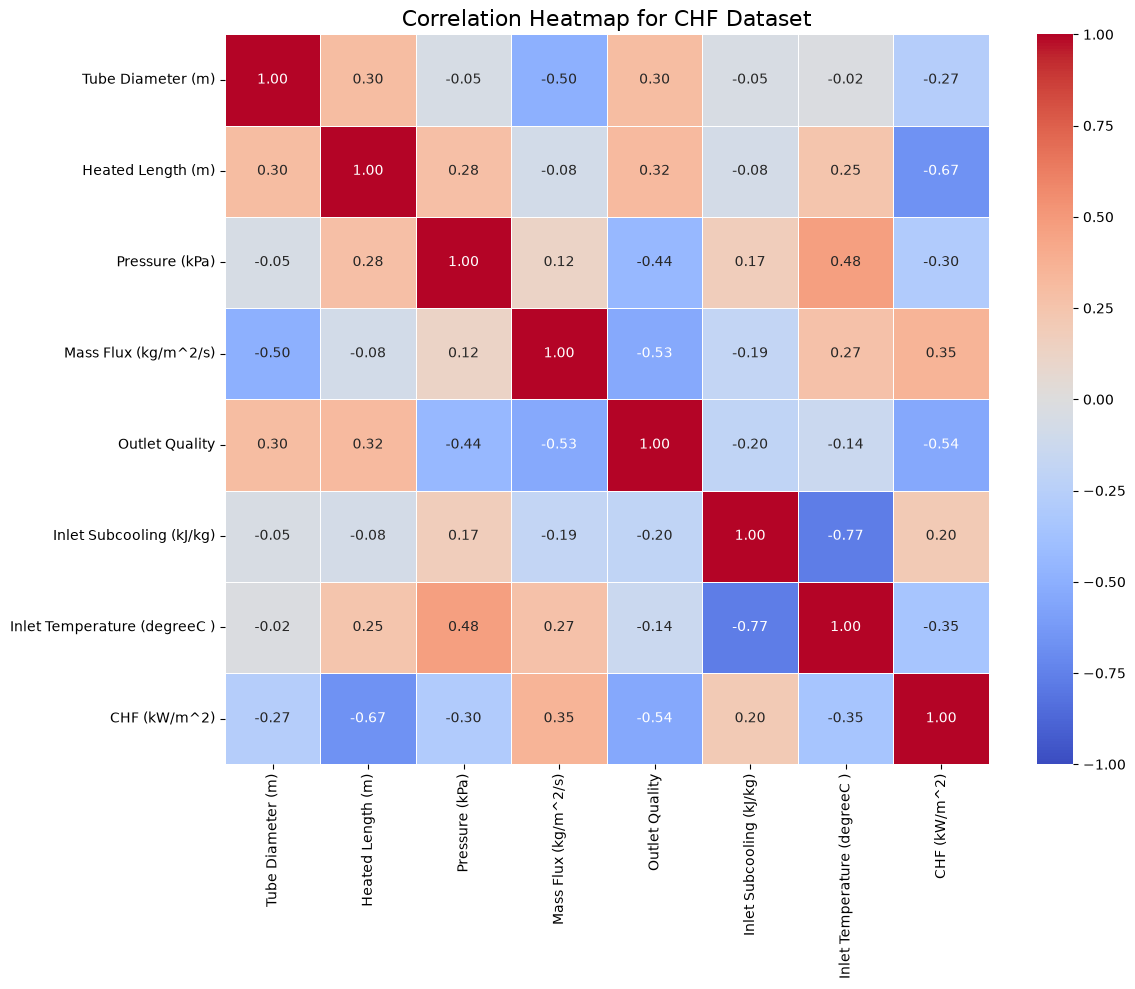

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap with seaborn
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=.5, 
            vmin=-1, 
            vmax=1)

# Add a title
plt.title('Correlation Heatmap for CHF Dataset', fontsize=16)
plt.tight_layout()
plt.show()

Large absolute values show high correlation, larger is 1 bc CHF correlates to its self for example
The above is looking for linear correlation, can be used as guidance
Small -ve value suggests uncorrelated and not likely to be valuable feature

__What to look for in the correlation heatmap.__

Look along the CHF row (or down the column). Large absolute values suggest that feature provides useful information, and is likely to be a good discriminator in predicting the target. The largest value is CHF itself, but that is not very helpful! This essentially translates to `if I know what the CHF is, I can predict the CHF`! Looking at the other quantities, some are likely to be stronger predictors than others (heated length, outlet quality look promising, for example).

We can also look at correlations between potential features. In this case, high values are not desirable, because it implies redundant information would be used as inputs to the model. For example, Inlet subcooling is highly correlated with the inlet temperature. This makes sense. We probably should not use _both_ of these, since they are providing highly correlated information. 

To get us started, based on the information from the heatmap, we will use heated length, outlet quality and mass flux as our features. 

Feature selection is not generally the case of the more the merrier. It is particularly important to think critically about what information a variable might provide, and its predictive capacity. We should also use physics knowledge to inform decisions. For instance, _outlet quality_, _inlet temperature_ and _inlet subcooling_ have thermodynamic links, so arguably only one should be used in a given feature set.

Let's drop everything apart from our chosen features and the label.

---
> Note that the correlation heatmap only measures linear relationships. One of the main reasons we use Neural Networks is because they are excellent at finding complex, non-linear relationships. In fluid dynamics and thermodynamics, pressure and tube diameter are physically critical to boiling behavior. Later on, we can try running your model without dropping those columns and see if your model score improves!
---

In [8]:
df = df.drop('Tube Diameter (m)', axis=1)
#df = df.drop('Pressure (kPa)', axis=1)
#df = df.drop('Inlet Subcooling (kJ/kg)', axis=1)
df = df.drop('Inlet Temperature (degreeC )', axis=1)

### Separating the features and labels
Now we have cleaned the data, we are ready to generate our features (X) and label (y).

In [9]:
y_train = df['CHF (kW/m^2)'].copy() 
X_train = df.loc[:, df.columns != 'CHF (kW/m^2)'].copy() 

It's good practice to check this split worked as planned! We do not want to inadvertently train with our labels as features (if the CHF is X, what is the CHF? is quite a trivial problem)!

In [10]:
X_train.describe()

,Heated Length (m),Pressure (kPa),Mass Flux (kg/m^2/s),Outlet Quality,Inlet Subcooling (kJ/kg)
count,10424.000000,10424.000000,10424.000000,10424.000000,10424.000000
mean,2.712116,11666.547103,2164.410591,0.295521,508.722947
std,1.796855,4871.498383,1444.623995,0.240443,322.369499
min,0.250000,520.000000,100.000000,-0.497000,2.000000
25%,1.000000,7850.000000,1009.750000,0.132000,250.000000
50%,2.000000,12750.000000,1609.000000,0.285000,464.000000
75%,4.000000,14710.000000,3179.000000,0.422000,714.000000
max,6.050000,20000.000000,7964.000000,0.997000,1644.000000


In [11]:
y_train.describe()

count    10424.000000
mean      1736.025355
std       1332.573956
min        135.000000
25%        729.000000
50%       1395.000000
75%       2355.500000
max      14760.000000
Name: CHF (kW/m^2), dtype: float64

Finally, we will scale the features. In our dataset, features have wildly different scales. Mass Flux is in the thousands, while Outlet Quality is between -1 and 1. Neural Networks (like MLPRegressor) are notoriously sensitive to unscaled data. If you don't scale your data, the network struggles to update its weights properly. 

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)# returns zero mean and unit variance for each feature

## Running Models

We will use the machine learning package `scikit-learn` to perform the machine learning. 

### __Neural Network__

In [13]:
from sklearn.neural_network import MLPRegressor

You can read the documentation of the MLPRegressor class by running the cell below. Pay attention to the arguments the function can take. Most of them have default values, but the defaults will not necessarily work well for every problem. It is very likely you will need to perform a hyperparameter search to achieve good performance.

---

> Note: Running the cell below produces a lot of text. Depending on your version of Jupyter, you may want to click to the left of the cell after running it to collapse the ouput into a smaller scrollable window (this may be the default).

---

#### returns documentation for the class


In [14]:
MLPRegressor??

Init signature:
MLPRegressor(
    loss='squared_error',
    hidden_layer_sizes=(100,),
    activation='relu',
    *,
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    power_t=0.5,
    max_iter=200,
    shuffle=True,
    random_state=None,
    tol=0.0001,
    verbose=False,
    warm_start=False,
    momentum=0.9,
    nesterovs_momentum=True,
    early_stopping=False,
    validation_fraction=0.1,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    n_iter_no_change=10,
    max_fun=15000,
)
Source:        
class MLPRegressor(RegressorMixin, BaseMultilayerPerceptron):
    """Multi-layer Perceptron regressor.

    This model optimizes the squared error using LBFGS or stochastic gradient
    descent.

    .. versionadded:: 0.18

    Parameters
    ----------
    loss : {'squared_error', 'poisson'}, default='squared_error'
        The loss function to use when training the weights. Note that the
        "squared err

The class `MLPRegressor` can use stochastic gradient descent to train various linear algorithms. To get started, we will set `loss='squared_error'`. The argument `random_state=42` is useful to ensure repeatable results. The specific number 42  is arbitrary (42 is the answer to life, the universe, and everything according to Douglas Adams' comedic science fiction series, "The Hitchhiker's Guide to the Galaxy."). Finally, we set learning_rate=`constant` to use a fixed learning rate throughout the training. This is chosen for simplicity. Other options are `invscaling` and `adaptive` which dynamically set the learning rate at each update of the parameters according to the schedule described in the documentation in the cell above. The specific value we use is set by the argument `learning_rate_init`. (Note that scikit-learn uses `learning_rate_init` to mean initial learning rate, whereas we had used `alpha` in the lectures. Both are common nomenclature). To further add to the confusion, the regularisation hyperparameter ($\lambda$ in the lectures) is referred to as `alpha` in scikit learn! 

In [15]:
model = MLPRegressor(learning_rate='constant', learning_rate_init=0.005, random_state=42, max_iter=2000)
model.fit(X_train, y_train) # do the training

,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.005
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5

We have trained a neural network regression model! Let's see how it did __on the validation data__ (not test data yet as we have not optimised hyperparameters). First we download the validation data, and prepare it in exactly the same way as we prepared the training data:

In [16]:
df_val = pd.read_csv('https://github.com/MartianonEarth/ai4nth-summer-school/blob/ai-nth-bundle-2026/datasets/chf_val.csv?raw=true')
df_val = df_val.drop('Number', axis=1)
df_val = df_val.drop('Reference ID', axis=1)
df_val = df_val.drop('Reference name', axis=1)
df_val = df_val.drop('Tube Diameter (m)', axis=1)
#df_val = df_val.drop('Pressure (kPa)', axis=1)
#df_val = df_val.drop('Inlet Subcooling (kJ/kg)', axis=1)
df_val = df_val.drop('Inlet Temperature (degreeC )', axis=1)
y_val = df_val['CHF (kW/m^2)'].copy() 
X_val = df_val.loc[:, df.columns != 'CHF (kW/m^2)'].copy()

# ONLY transform validation and test data (do not fit again to prevent data leakage). So the scaling is consistent between all datasets.
X_val = scaler.transform(X_val)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on the validation set
y_pred = model.predict(X_val)

# Compute regression metrics
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_val, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 200.54
Root Mean Squared Error (RMSE): 283.24
R-squared (R2): 0.94


__Mean Absolute Error (MAE):__ This is the easiest to interpret. It represents the average absolute difference between your predictions and the actual values. If your MAE is 418, your predictions are off by 418 $kW/m^2$ on average.

__Root Mean Squared Error (RMSE):__ This also measures the average error, but because it squares the errors before averaging them, it heavily penalizes larger mistakes. It is very useful if you want to ensure your model avoids making huge outlier predictions.

__R-squared (R²):__ This is a score that generally falls between 0.0 and 1.0. It represents the proportion of the variance in your target variable that is explained by your model. An R² of 1.0 is a perfect fit, while an R² of 0.0 means your model is essentially just guessing the average CHF value every time. (Note: R² can technically be negative if your model performs worse than just predicting the average).

#### HyperParameter Tuning
In the cells below, we will perform a basic hyperparameter search to get you started. This is not exhaustive, but may do better than previous accuracy (we hope!). Scikit-learn has a few options for hyperparameter searches built in. These use k-fold cross-validation. For more info, see [here](https://scikit-learn.org/1.5/api/sklearn.model_selection.html#hyper-parameter-optimizers). However, since we have an explicit validation set created above, we will implement our own simple grid search rather than use the k-fold cross-validation. A random search may also be useful instead of a grid search (see [ParameterSampler](https://scikit-learn.org/1.5/modules/generated/sklearn.model_selection.ParameterSampler.html#sklearn.model_selection.ParameterSampler) to get started on implementing a random search). 

We will attempt to optimise the regularisation type and the regularisation parameter $\lambda$ (i.e. $\alpha$ in scikit-learn). You can search over other hyperparameters.


In [18]:
import numpy as np
from sklearn.model_selection import ParameterGrid
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (20,20), (50,10)], # (50,1)=50 neurons in 1 hidden layer, (50, 50) =50 neurons in 2 hidden layers,  different number of hideen layers and neurons
    'learning_rate_init': np.logspace(-5, -1, 5), # numpy to try 5 values between 10^-5 and 10^-1 for learning rate, alpha
    #'alpha': (0.001, 0.1),
    #'batch_size': (25,50)
    #'activation': ['relu', 'logistic']
}

# Initialize best_r2 to negative infinity (since R2 can technically be negative)
best_r2 = -float('inf') 
best_model = None
best_params = None

print(f"Starting hyperparameter search over {len(list(ParameterGrid(param_grid)))} combinations...")

for params in ParameterGrid(param_grid):
    model = MLPRegressor(**params, learning_rate='constant', random_state=42, max_iter=5000) #learning rate is alpha in the lecture

    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val) # check how is performing on the validation set

    # Compute metrics
    #mae = mean_absolute_error(y_val, y_pred)
    #mse = mean_squared_error(y_val, y_pred)
    #rmse = np.sqrt(mse) 
    r2 = r2_score(y_val, y_pred) # to decide our best model
    
    # Check if this model is the best one so far and then store the model
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_params = params
        
print("-" * 30)
print("Best Params:", best_params)
print(f"Best Validation R2: {best_r2:.3f}")

Starting hyperparameter search over 25 combinations...


/home/katsa1k/apps/anaconda3/envs/ai4nth/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katsa1k/apps/anaconda3/envs/ai4nth/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katsa1k/apps/anaconda3/envs/ai4nth/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katsa1k/apps/anaconda3/envs/ai4nth/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization

------------------------------
Best Params: {'hidden_layer_sizes': (50, 50), 'learning_rate_init': np.float64(0.01)}
Best Validation R2: 0.952


This improvement in the R-squared score is a step in the right direction, but you can do better!

Note that some models failed to converge. That just means that that particular combination of hyperparameters was a poor choice.

# Things to try:
- Revisit feature selection and hyperparameter search. You can put any of the arguments MLPRegressor accepts (see output of the MLPRegressor?? cell above) into the param_grid.
- Different choices of feature cleanup or feature engineering is likely to yield significant gains. Play around with this.
- How does your own neural network developed in Lab 1 perform? 

## Checking on the test data (hidden labels) and submitting scores.

# STOP!! READ THE INFO BELOW BEFORE PROCEEDING
---
> Note: You should only run the cells below __after__ you have decided upon your best model. Repeatedly running this cell and optimising hyperparameters against the test data is bad practice (even if by trial and error rather than incorporating this code into the grid search). You should think of the data in your training and validation sets as the only data you have available to you when selecting the model, while the test set should only be used to test the final model. You would therefore only run the cell below once, and certainly should not change decisions about hyperparameters or data cleanup based on the score you receive in this cell.
---

Download and prepare the test data:

In [21]:
df_test = pd.read_csv('https://github.com/MartianonEarth/ai4nth-summer-school/blob/ai-nth-bundle-2026/datasets/chf_test.csv?raw=true')
df_test = df_test.drop('Number', axis=1)
df_test = df_test.drop('Reference ID', axis=1)
df_test = df_test.drop('Reference name', axis=1)
df_test = df_test.drop('Tube Diameter (m)', axis=1)
#df_test = df_test.drop('Pressure (kPa)', axis=1)
#df_test = df_test.drop('Inlet Subcooling (kJ/kg)', axis=1)
df_test = df_test.drop('Inlet Temperature (degreeC )', axis=1)
y_test = df_test['CHF (kW/m^2)'].copy() 
X_test = df_test.loc[:, df.columns != 'CHF (kW/m^2)'].copy()

# ONLY transform validation and test data (do not fit again to prevent data leakage). So the scaling is consistent between all datasets.
X_test = scaler.transform(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on the validation set
y_pred = best_model.predict(X_test)

# Compute regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 110.48
Root Mean Squared Error (RMSE): 165.43
R-squared (R2): 0.96
